# BHT Basin Visualization

This notebook demonstrates **basin map visualization** for the Basin Hierarchy Tree (BHT) using the refactored public API (`ta.ImageFilter` and `ta.GraphFilter`).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import topapprox as ta

## 1. Image basin map (2-D)

Create a small 2-D image and visualise its basins at different persistence thresholds.

In [2]:
# A 5x5 image with several local minima of varying depth
# Minima at positions (1,1)=1, (1,3)=3, (3,1)=4, (3,3)=0 separated by ridges at 7-8.
img = np.array([
    [8, 7, 8, 7, 8],
    [7, 1, 7, 3, 7],
    [8, 7, 8, 7, 8],
    [7, 4, 7, 0, 7],
    [8, 7, 8, 7, 8],
], dtype=float)

tfi = ta.ImageFilter(img, method="python")

# Show persistence diagram
pd = tfi.get_persistence(reduced=False)
print("Persistence diagram [birth, death, birth_v, death_v, size, depth, height]:")
print(pd)

Persistence diagram [birth, death, birth_v, death_v, size, depth, height]:
[[ 3.  7.  8. 13.  2.  1.  0.]
 [ 4.  7. 16. 11.  2.  2.  0.]
 [ 1.  7.  6.  7.  4.  1.  1.]
 [ 0. inf 18. -1. inf  0.  2.]]


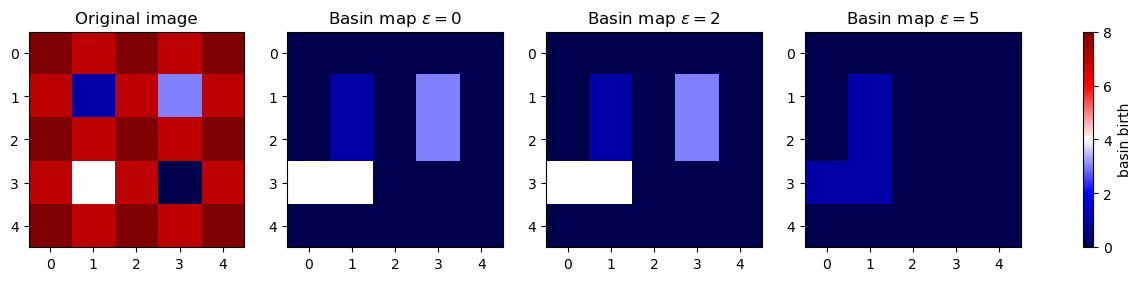

In [17]:
# Compare original image and basin maps at different epsilon
epsilons = [0, 2, 5]

fig, axes = plt.subplots(1, len(epsilons) + 1, figsize=(4 * (len(epsilons) + 1), 4))

# Original image
# Precompute basin maps and use consistent color scaling
vmin = np.nanmin(img)
vmax = np.nanmax(img)

im0 = axes[0].imshow(img, cmap="seismic", origin="upper", vmin=vmin, vmax=vmax)
axes[0].set_title("Original image")

basin_maps = [tfi.basin_map(eps) for eps in epsilons]
for i, (eps, basin) in enumerate(zip(epsilons, basin_maps)):
    im = axes[i + 1].imshow(basin, cmap="seismic", origin="upper", vmin=vmin, vmax=vmax)
    axes[i + 1].set_title(f"Basin map $\\varepsilon={eps}$")

# One shared colorbar for all basin maps
fig.colorbar(im, ax=axes, shrink=0.7, label="basin birth")

#plt.tight_layout()
plt.show()

### Using the convenience function `plot_basin_image`

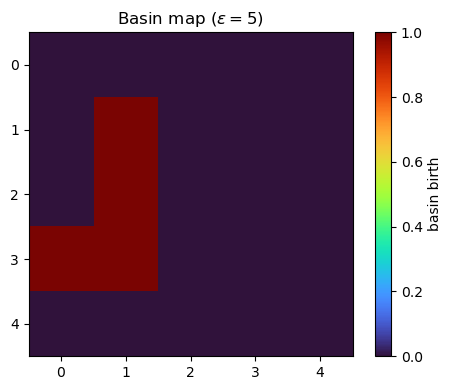

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
ta.plot_basin_image(tfi, epsilon=5, ax=ax)
plt.colorbar(ax.images[0], ax=ax, label="basin birth")
plt.tight_layout()
plt.show()

## 2. Larger image example

A synthetic landscape with multiple peaks to show basin hierarchy more clearly.

/var/folders/g6/d1w60lkx7f315zbszv_nvklw0000gn/T/ipykernel_32664/4027625761.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


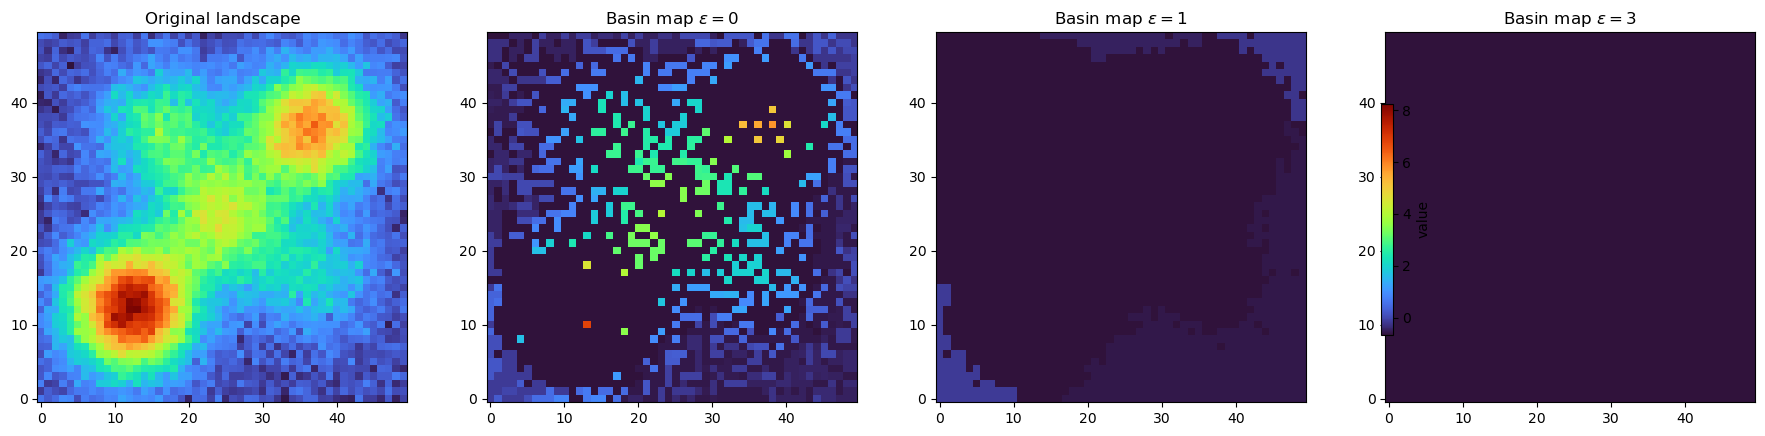

In [18]:
# Synthetic landscape: sum of Gaussians with different heights
np.random.seed(0)
N = 50
x = np.linspace(-3, 3, N)
X, Y = np.meshgrid(x, x)

# Several peaks/valleys
centres = [(-1.5, -1.5, 8), (1.5, 1.5, 6), (0, 0, 4), (-1, 1.5, 3), (1.5, -1, 2)]
landscape = np.zeros((N, N))
for cx, cy, h in centres:
    landscape += h * np.exp(-((X - cx)**2 + (Y - cy)**2))

# Add small noise
landscape += 0.3 * np.random.randn(N, N)

tfi_big = ta.ImageFilter(landscape, method="python")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
vmin = np.nanmin(landscape)
vmax = np.nanmax(landscape)

im0 = axes[0].imshow(landscape, cmap="turbo", origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("Original landscape")

for i, eps in enumerate([0, 1, 3]):
    basin = tfi_big.basin_map(eps)
    axes[i + 1].imshow(basin, cmap="turbo", origin="lower", vmin=vmin, vmax=vmax)
    axes[i + 1].set_title(f"Basin map $\\varepsilon={eps}$")

fig.colorbar(im0, ax=axes, shrink=0.75, label="value")
plt.tight_layout()
plt.show()

## 3. Graph basin map

Build a graph with faces and visualise basins on the graph nodes.

In [6]:
import networkx as nx

# A 3x3 grid graph with 4 quadrilateral faces
#
#   v0(3)---v1(8)---v2(4)
#     |       |       |
#   v3(7)---v4(2)---v5(6)
#     |       |       |
#   v6(5)---v7(9)---v8(1)
#
# Local minima at v8=1, v4=2, v0=3 separated by saddle points.

F = [
    [0, 1, 4, 3],  # top-left quad
    [1, 2, 5, 4],  # top-right quad
    [3, 4, 7, 6],  # bottom-left quad
    [4, 5, 8, 7],  # bottom-right quad
]
H = [[0, 1, 2, 5, 8, 7, 6, 3]]  # outer boundary

signal = np.array([3.0, 8.0, 4.0,
                   7.0, 2.0, 6.0,
                   5.0, 9.0, 1.0])

# Grid positions for nice layout
pos = {i: (i % 3, -(i // 3)) for i in range(9)}

tfg = ta.GraphFilter(method="python")
tfg.compute_gwf(F=F, H=H, signal=signal)

pd = tfg.bht.get_persistence(reduced=False)
print("Persistence diagram [birth, death, birth_v, death_v, size, depth, height]:")
print(pd)

Persistence diagram [birth, death, birth_v, death_v, size, depth, height]:
[]


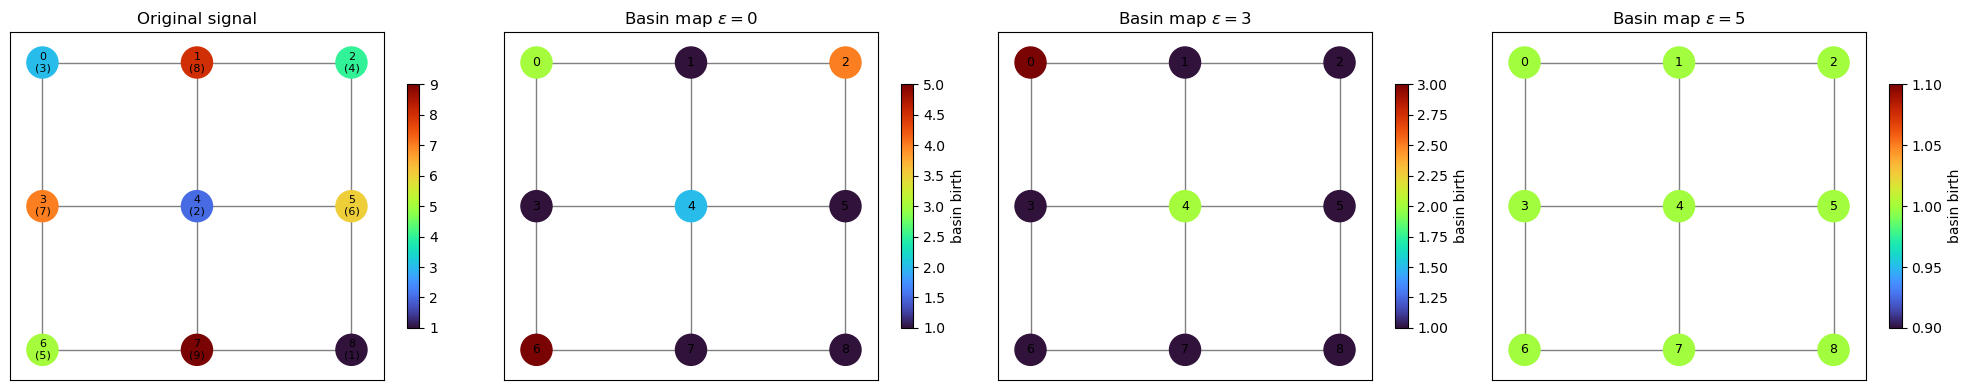

In [7]:
# Visualise basin maps on the graph at different thresholds
epsilons = [0, 3, 5]
fig, axes = plt.subplots(1, len(epsilons) + 1, figsize=(5 * (len(epsilons) + 1), 4))

# Build the networkx graph from original (non-auxiliary) edges
G = nx.Graph()
G.add_nodes_from(range(9))
for u, v in tfg.gwf.E:
    if u < 9 and v < 9:
        G.add_edge(int(u), int(v))

# Original signal on graph
nx.draw_networkx_edges(G, pos, ax=axes[0], edge_color="gray")
nc0 = nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color=signal, cmap="turbo", node_size=500)
nx.draw_networkx_labels(G, pos, ax=axes[0], font_size=8,
                        labels={i: f"{i}\n({signal[i]:.0f})" for i in range(9)})
axes[0].set_title("Original signal")
fig.colorbar(nc0, ax=axes[0], shrink=0.7)

# Basin maps
for i, eps in enumerate(epsilons):
    labels = tfg.basin_map(eps)
    nx.draw_networkx_edges(G, pos, ax=axes[i + 1], edge_color="gray")
    nc = nx.draw_networkx_nodes(G, pos, ax=axes[i + 1], node_color=labels, cmap="turbo", node_size=500)
    nx.draw_networkx_labels(G, pos, ax=axes[i + 1], font_size=9)
    axes[i + 1].set_title(f"Basin map $\\varepsilon={eps}$")
    fig.colorbar(nc, ax=axes[i + 1], shrink=0.7, label="basin birth")

plt.tight_layout()
plt.show()

### Using the convenience function `plot_basin_graph`

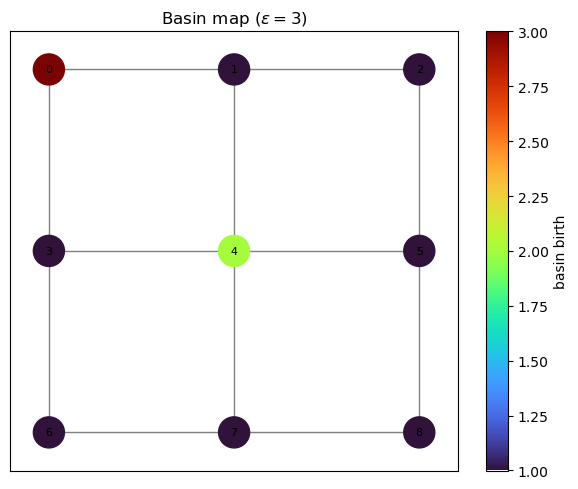

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ta.plot_basin_graph(tfg, epsilon=3, pos=pos, ax=ax, with_labels=True, node_size=500)
plt.tight_layout()
plt.show()

## 4. Image constructed from graph (from_array)

`GraphFilter.from_array` converts a 2-D image into a graph with faces, which can also be visualised with basin maps.

In [ ]:
# Use the same image through the graph interface
img2 = np.array([
    [5, 4, 5, 6, 7],
    [4, 1, 4, 5, 6],
    [5, 4, 5, 4, 5],
    [6, 5, 4, 0, 4],
    [7, 6, 5, 4, 5],
], dtype=float)

tfg2 = ta.GraphFilter(img2, method="python")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img2, cmap="turbo", origin="upper")
axes[0].set_title("Original image")

for i, eps in enumerate([0, 3]):
    basin = tfg2.basin_map(eps)
    axes[i + 1].imshow(basin, cmap="turbo", origin="upper")
    axes[i + 1].set_title(f"Graph basin map $\\varepsilon={eps}$")

plt.tight_layout()
plt.show()

## 5. Comparing basin map with filtered image

The basin map shows **which basin each vertex belongs to**, while the filtered image shows the **modified function values**. They convey complementary information.

In [ ]:
eps = 2
tfi2 = ta.ImageFilter(landscape, method="python")
filtered = tfi2.low_pers_filter(eps)
basin = tfi2.basin_map(eps)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(landscape, cmap="turbo", origin="lower")
axes[0].set_title("Original")

axes[1].imshow(filtered, cmap="turbo", origin="lower")
axes[1].set_title(f"Filtered ($\\varepsilon={eps}$)")

im2 = axes[2].imshow(basin, cmap="turbo", origin="lower")
axes[2].set_title(f"Basin map ($\\varepsilon={eps}$)")
fig.colorbar(im2, ax=axes[2], shrink=0.7, label="basin birth")

plt.tight_layout()
plt.show()